In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Setup & Load
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats
import warnings
import time
import lightgbm as lgb
from google.colab import drive

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/csao_outputs/'

# ── Load test features
print('Loading test features...')
test_df = pd.read_csv(BASE + 'lgbm_test_features_v2.csv')
print(f'  test_df shape : {test_df.shape}')
print(f'  All columns   : {list(test_df.columns)}')

# ── Auto-detect label column
LABEL_CANDIDATES = ['label', 'label_addon_added', 'target', 'is_added', 'y']
LABEL_COL = None
for c in LABEL_CANDIDATES:
    if c in test_df.columns:
        LABEL_COL = c
        break
if LABEL_COL is None:
    raise ValueError(f"Could not find label column. Columns are: {list(test_df.columns)}")
print(f'  ✅ Label column detected: "{LABEL_COL}"')
test_df = test_df.rename(columns={LABEL_COL: 'label'})

# ── Load model
model = lgb.Booster(model_file=BASE + 'csao_ranker.lgb')
print(f'  Model loaded. Best iteration: {model.best_iteration}')

# ── Load side tables for segmentation
users_df    = pd.read_csv(BASE + 'users.csv')
sessions_df = pd.read_csv(BASE + 'sessions_clean.csv')
items_df    = pd.read_csv(BASE + 'items_clean.csv')[['item_id','effective_category','price']]

# ── Join segmentation columns
test_df = test_df.merge(sessions_df[['session_id','meal_time_bucket']].drop_duplicates(),
                        on='session_id', how='left')
test_df = test_df.merge(users_df[['user_id','user_segment','avg_order_value']].drop_duplicates(),
                        on='user_id', how='left')
test_df = test_df.merge(
    items_df.rename(columns={'item_id':'candidate_item_id',
                              'effective_category':'cand_category_raw',
                              'price':'cand_price'}),
    on='candidate_item_id', how='left'
)

# ── Get EXACT feature names the model was trained on
FEATURE_COLS = model.feature_name()
print(f'  Model expects {len(FEATURE_COLS)} features')
print(f'  Sample: {FEATURE_COLS[:8]}')

# ── Align: add any missing cols as 0, cast to float
for col in FEATURE_COLS:
    if col not in test_df.columns:
        test_df[col] = 0
        print(f'  ⚠ Missing col padded as 0: {col}')

test_df[FEATURE_COLS] = test_df[FEATURE_COLS].astype(float)
print(f'  ✅ All {len(FEATURE_COLS)} feature columns aligned')

# ── Score
test_df['model_score']   = model.predict(test_df[FEATURE_COLS], num_iteration=model.best_iteration)
test_df['control_score'] = test_df['retrieval_score']
test_df['_group_key']    = test_df['session_id'].astype(str) + '_' + test_df['step_number'].astype(str)

print(f'\n✅ Data ready.')
print(f'  Test rows        : {len(test_df):,}')
print(f'  Unique groups    : {test_df["_group_key"].nunique():,}')
print(f'  Positive rate    : {test_df["label"].mean():.4f}')
print(f'  Model score range: [{test_df["model_score"].min():.4f}, {test_df["model_score"].max():.4f}]')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading test features...
  test_df shape : (533556, 75)
  All columns   : ['session_id', 'step_number', 'candidate_item_id', 'retrieval_score', 'src_cooc', 'src_ctx', 'src_rule', 'label_addon_added', 'hour_of_day', 'is_weekend', 'user_id', 'cart_item_count', 'cart_total_value', 'cart_has_main', 'cart_has_beverage', 'cart_has_dessert', 'cart_has_side', 'missing_beverage_flag', 'missing_dessert_flag', 'missing_side_flag', 'restaurant_id', 'price', 'popularity_score', 'historical_attach_rate', 'dish_subtype', 'order_count_90d', 'recency_days', 'avg_order_value', 'veg_preference_ratio', 'dessert_affinity_score', 'beverage_affinity_score', 'price_sensitivity_score', 'city', 'city_rest', 'aggregate_rating', 'is_chain', 'order_volume_30d', 'overall_attach_rate', 'meal_time_specificity', 'meal_time_overlap', 'step_decay', 'x_missing_bev_aff', 'x_missing_des_aff', 'x_

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Core Metric Functions
# ─────────────────────────────────────────────────────────────

def dcg_at_k(relevance, k):
    r = np.array(relevance[:k], dtype=float)
    if r.size == 0:
        return 0.0
    return np.sum(r / np.log2(np.arange(2, r.size + 2)))

def ndcg_at_k(labels_sorted_by_score, k):
    actual = dcg_at_k(labels_sorted_by_score, k)
    ideal  = dcg_at_k(sorted(labels_sorted_by_score, reverse=True), k)
    return actual / ideal if ideal > 0 else 0.0

def per_group_metrics(df, score_col, label_col='label', group_col='_group_key', ks=(5, 8, 10)):
    """
    Returns DataFrame with one row per group:
    ndcg@k, precision@k, recall@k, hit@k, mrr, hit@1
    """
    records = []
    for gk, grp in df.groupby(group_col):
        grp_sorted = grp.sort_values(score_col, ascending=False)
        labels     = grp_sorted[label_col].tolist()
        n_pos      = sum(labels)
        if n_pos == 0:
            continue

        rec = {'group_key': gk}
        for k in ks:
            top_k_labels  = labels[:k]
            n_hits         = sum(top_k_labels)
            rec[f'ndcg@{k}']      = ndcg_at_k(labels, k)
            rec[f'precision@{k}'] = n_hits / k
            rec[f'recall@{k}']    = n_hits / n_pos
            rec[f'hit@{k}']       = int(n_hits > 0)

        # MRR
        for rank, lbl in enumerate(labels, 1):
            if lbl == 1:
                rec['mrr'] = 1.0 / rank
                break
        else:
            rec['mrr'] = 0.0

        rec['hit@1'] = int(labels[0] == 1)
        records.append(rec)

    return pd.DataFrame(records)

print('✅ Metric functions defined.')

✅ Metric functions defined.


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Offline A/B: Per-Group Metrics Control vs Treatment
# ─────────────────────────────────────────────────────────────

print('Computing per-group metrics for Control (retrieval_score)...')
control_grp_df   = per_group_metrics(test_df, score_col='control_score')

print('Computing per-group metrics for Treatment (Binary v1)...')
treatment_grp_df = per_group_metrics(test_df, score_col='model_score')

print(f'  Groups evaluated: {len(control_grp_df):,}')

ks   = [5, 8, 10]
cols = ([f'ndcg@{k}' for k in ks] + [f'precision@{k}' for k in ks] +
        [f'recall@{k}' for k in ks] + [f'hit@{k}' for k in ks] + ['mrr', 'hit@1'])

summary_rows = []
for col in cols:
    if col not in control_grp_df.columns:
        continue
    ctrl_mean  = control_grp_df[col].mean()
    treat_mean = treatment_grp_df[col].mean()
    lift       = (treat_mean - ctrl_mean) / (ctrl_mean + 1e-9) * 100
    summary_rows.append({'Metric': col, 'Control': ctrl_mean,
                         'Treatment': treat_mean, 'Lift %': lift})

summary_df = pd.DataFrame(summary_rows)
summary_df['Control']   = summary_df['Control'].map('{:.4f}'.format)
summary_df['Treatment'] = summary_df['Treatment'].map('{:.4f}'.format)
summary_df['Lift %']    = summary_df['Lift %'].map('{:+.1f}%'.format)

print('\n📊 Offline A/B Metric Comparison:')
print(summary_df.to_string(index=False))

Computing per-group metrics for Control (retrieval_score)...
Computing per-group metrics for Treatment (Binary v1)...
  Groups evaluated: 20,246

📊 Offline A/B Metric Comparison:
      Metric Control Treatment Lift %
      ndcg@5  0.3564    0.4161 +16.7%
      ndcg@8  0.3987    0.4556 +14.3%
     ndcg@10  0.4183    0.4755 +13.7%
 precision@5  0.1027    0.1196 +16.5%
 precision@8  0.0799    0.0895 +12.0%
precision@10  0.0705    0.0783 +11.0%
    recall@5  0.5133    0.5982 +16.5%
    recall@8  0.6389    0.7158 +12.0%
   recall@10  0.7055    0.7833 +11.0%
       hit@5  0.5133    0.5982 +16.5%
       hit@8  0.6389    0.7158 +12.0%
      hit@10  0.7055    0.7833 +11.0%
         mrr  0.3485    0.3941 +13.1%
       hit@1  0.1856    0.2133 +14.9%


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Statistical Significance Tests
# ─────────────────────────────────────────────────────────────

from scipy.stats import ttest_rel, wilcoxon

merged = control_grp_df.set_index('group_key').join(
    treatment_grp_df.set_index('group_key'), lsuffix='_ctrl', rsuffix='_treat'
).dropna()

key_metrics = ['ndcg@8', 'recall@8', 'mrr', 'hit@1']
sig_rows = []

for m in key_metrics:
    ctrl_vals  = merged[f'{m}_ctrl'].values
    treat_vals = merged[f'{m}_treat'].values
    diff       = treat_vals - ctrl_vals

    t_stat, p_val = ttest_rel(treat_vals, ctrl_vals)
    cohen_d       = diff.mean() / (diff.std() + 1e-9)
    n             = len(diff)
    se            = diff.std() / np.sqrt(n)
    ci_low        = diff.mean() - 1.96 * se
    ci_high       = diff.mean() + 1.96 * se
    _, w_p        = wilcoxon(treat_vals, ctrl_vals) if not np.all(diff == 0) else (0, 1.0)

    sig_rows.append({
        'Metric'      : m,
        'Ctrl Mean'   : f'{ctrl_vals.mean():.4f}',
        'Treat Mean'  : f'{treat_vals.mean():.4f}',
        'Mean Diff'   : f'{diff.mean():+.4f}',
        '95% CI'      : f'[{ci_low:+.4f}, {ci_high:+.4f}]',
        'p-val (t)'   : f'{p_val:.2e}',
        'p-val (W)'   : f'{w_p:.2e}',
        'Cohen d'     : f'{cohen_d:.3f}',
        'Significant?': '✅ Yes' if p_val < 0.05 else '❌ No'
    })

sig_df = pd.DataFrame(sig_rows)
print('\n📊 Statistical Significance — Paired t-test & Wilcoxon')
print(sig_df.to_string(index=False))
print('\nNote: Cohen d > 0.2 = small effect, > 0.5 = medium, > 0.8 = large')


📊 Statistical Significance — Paired t-test & Wilcoxon
  Metric Ctrl Mean Treat Mean Mean Diff             95% CI p-val (t) p-val (W) Cohen d Significant?
  ndcg@8    0.3987     0.4556   +0.0570 [+0.0546, +0.0593]  0.00e+00  0.00e+00   0.336        ✅ Yes
recall@8    0.6389     0.7158   +0.0769 [+0.0724, +0.0813] 7.17e-243 2.02e-236   0.237        ✅ Yes
     mrr    0.3485     0.3941   +0.0456 [+0.0434, +0.0478]  0.00e+00  0.00e+00   0.287        ✅ Yes
   hit@1    0.1856     0.2133   +0.0277 [+0.0244, +0.0309]  7.82e-63  2.03e-62   0.118        ✅ Yes

Note: Cohen d > 0.2 = small effect, > 0.5 = medium, > 0.8 = large


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Business Metric Projections
# ─────────────────────────────────────────────────────────────

AVG_ITEM_PRICE_INR     = 120.0
BASELINE_AVG_ORDER_INR = 450.0
DAILY_SESSIONS         = 5_000_000
DISPLAY_K              = 8

ctrl_acceptance  = control_grp_df['recall@8'].mean()
treat_acceptance = treatment_grp_df['recall@8'].mean()

ctrl_attach_per_imp  = control_grp_df['precision@8'].mean() * DISPLAY_K
treat_attach_per_imp = treatment_grp_df['precision@8'].mean() * DISPLAY_K

ctrl_aov_lift_per_session  = ctrl_acceptance  * ctrl_attach_per_imp  * AVG_ITEM_PRICE_INR
treat_aov_lift_per_session = treat_acceptance * treat_attach_per_imp * AVG_ITEM_PRICE_INR

C2O_UPLIFT_PER_HIT = 0.05
BASELINE_C2O_RATE  = 0.80
ctrl_c2o  = BASELINE_C2O_RATE + ctrl_acceptance  * C2O_UPLIFT_PER_HIT
treat_c2o = BASELINE_C2O_RATE + treat_acceptance * C2O_UPLIFT_PER_HIT

ctrl_ctr  = control_grp_df['hit@8'].mean()
treat_ctr = treatment_grp_df['hit@8'].mean()

incremental_aov_per_sess = treat_aov_lift_per_session - ctrl_aov_lift_per_session
daily_revenue_lift_inr   = incremental_aov_per_sess * DAILY_SESSIONS

print('=' * 65)
print('  BUSINESS METRIC PROJECTIONS — Control vs Treatment')
print('=' * 65)
print(f'  Avg add-on price        : Rs.{AVG_ITEM_PRICE_INR:.0f}')
print(f'  Baseline avg order val  : Rs.{BASELINE_AVG_ORDER_INR:.0f}')
print(f'  Daily CSAO impressions  : {DAILY_SESSIONS:,.0f}')
print('-' * 65)

metrics_biz = [
    ('Acceptance Rate (Recall@8)',     f'{ctrl_acceptance:.4f}',          f'{treat_acceptance:.4f}',
     f'{(treat_acceptance-ctrl_acceptance)/ctrl_acceptance*100:+.1f}%'),
    ('Attach Rate (items/impression)', f'{ctrl_attach_per_imp:.4f}',      f'{treat_attach_per_imp:.4f}',
     f'{(treat_attach_per_imp-ctrl_attach_per_imp)/ctrl_attach_per_imp*100:+.1f}%'),
    ('AOV Lift per Session (Rs.)',     f'Rs.{ctrl_aov_lift_per_session:.2f}', f'Rs.{treat_aov_lift_per_session:.2f}',
     f'Rs.{treat_aov_lift_per_session-ctrl_aov_lift_per_session:+.2f}'),
    ('CTR Upper Bound (Hit@8)',        f'{ctrl_ctr:.4f}',                 f'{treat_ctr:.4f}',
     f'{(treat_ctr-ctrl_ctr)/ctrl_ctr*100:+.1f}%'),
    ('C2O Rate Proxy',                 f'{ctrl_c2o:.4f}',                 f'{treat_c2o:.4f}',
     f'{(treat_c2o-ctrl_c2o)/ctrl_c2o*100:+.2f}%'),
    ('Daily Revenue Lift (Rs.)',       '—',                               f'Rs.{daily_revenue_lift_inr:,.0f}', ''),
]

print(f'  {"Metric":<38} {"Control":>12} {"Treatment":>14} {"Delta":>10}')
print('-' * 78)
for row in metrics_biz:
    print(f'  {row[0]:<38} {row[1]:>12} {row[2]:>14} {row[3]:>10}')

print(f'\n  AOV lift as % of baseline : {incremental_aov_per_sess/BASELINE_AVG_ORDER_INR*100:.2f}%')
print(f'  Daily revenue uplift      : Rs.{daily_revenue_lift_inr/1e5:.1f}L  (at {DAILY_SESSIONS/1e6:.0f}M impressions)')

  BUSINESS METRIC PROJECTIONS — Control vs Treatment
  Avg add-on price        : Rs.120
  Baseline avg order val  : Rs.450
  Daily CSAO impressions  : 5,000,000
-----------------------------------------------------------------
  Metric                                      Control      Treatment      Delta
------------------------------------------------------------------------------
  Acceptance Rate (Recall@8)                   0.6389         0.7158     +12.0%
  Attach Rate (items/impression)               0.6389         0.7158     +12.0%
  AOV Lift per Session (Rs.)                 Rs.48.99       Rs.61.48  Rs.+12.49
  CTR Upper Bound (Hit@8)                      0.6389         0.7158     +12.0%
  C2O Rate Proxy                               0.8319         0.8358     +0.46%
  Daily Revenue Lift (Rs.)                          —  Rs.62,470,721           

  AOV lift as % of baseline : 2.78%
  Daily revenue uplift      : Rs.624.7L  (at 5M impressions)


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Segment-Level Breakdown
# ─────────────────────────────────────────────────────────────

def segment_breakdown(df, score_col, label_col='label', segment_col=None, k=8):
    rows = []
    for seg_val, seg_grp in df.groupby(segment_col):
        seg_records = []
        for gk, grp in seg_grp.groupby('_group_key'):
            grp_s  = grp.sort_values(score_col, ascending=False)
            labels = grp_s[label_col].tolist()
            n_pos  = sum(labels)
            if n_pos == 0:
                continue
            seg_records.append({
                'ndcg'  : ndcg_at_k(labels, k),
                'recall': sum(labels[:k]) / n_pos,
                'hit'   : int(sum(labels[:k]) > 0),
            })
        if not seg_records:
            continue
        sdf = pd.DataFrame(seg_records)
        rows.append({
            'Segment'     : seg_val,
            'N Groups'    : len(sdf),
            f'NDCG@{k}'   : sdf['ndcg'].mean(),
            f'Recall@{k}' : sdf['recall'].mean(),
            f'Hit@{k}'    : sdf['hit'].mean(),
        })
    return pd.DataFrame(rows)

K = 8

def compare_segments(ctrl_seg, treat_seg, k=8):
    comp = ctrl_seg.merge(treat_seg, on='Segment', suffixes=('_ctrl','_treat'))
    comp[f'NDCG@{k} Lift']   = ((comp[f'NDCG@{k}_treat']   - comp[f'NDCG@{k}_ctrl'])   / comp[f'NDCG@{k}_ctrl']   * 100).map('{:+.1f}%'.format)
    comp[f'Recall@{k} Lift'] = ((comp[f'Recall@{k}_treat'] - comp[f'Recall@{k}_ctrl']) / comp[f'Recall@{k}_ctrl'] * 100).map('{:+.1f}%'.format)
    return comp[['Segment', f'NDCG@{k}_ctrl', f'NDCG@{k}_treat', f'NDCG@{k} Lift',
                 f'Recall@{k}_ctrl', f'Recall@{k}_treat', f'Recall@{k} Lift']]

print('📊 Segment: meal_time_bucket')
mt_compare = compare_segments(
    segment_breakdown(test_df, 'control_score', segment_col='meal_time_bucket', k=K),
    segment_breakdown(test_df, 'model_score',   segment_col='meal_time_bucket', k=K), K)
print(mt_compare.to_string(index=False))

print('\n📊 Segment: user_segment')
us_compare = compare_segments(
    segment_breakdown(test_df, 'control_score', segment_col='user_segment', k=K),
    segment_breakdown(test_df, 'model_score',   segment_col='user_segment', k=K), K)
print(us_compare.to_string(index=False))

print('\n📊 Segment: step_number')
sn_compare = compare_segments(
    segment_breakdown(test_df, 'control_score', segment_col='step_number', k=K),
    segment_breakdown(test_df, 'model_score',   segment_col='step_number', k=K), K)
print(sn_compare.to_string(index=False))

📊 Segment: meal_time_bucket
   Segment  NDCG@8_ctrl  NDCG@8_treat NDCG@8 Lift  Recall@8_ctrl  Recall@8_treat Recall@8 Lift
 breakfast     0.399171      0.433462       +8.6%       0.625904        0.668639         +6.8%
    dinner     0.412363      0.477812      +15.9%       0.655293        0.742941        +13.4%
late-night     0.392307      0.446862      +13.9%       0.632565        0.709040        +12.1%
     lunch     0.380620      0.431531      +13.4%       0.620203        0.688917        +11.1%

📊 Segment: user_segment
            Segment  NDCG@8_ctrl  NDCG@8_treat NDCG@8 Lift  Recall@8_ctrl  Recall@8_treat Recall@8 Lift
             budget     0.365469      0.414460      +13.4%       0.586393        0.663067        +13.1%
frequent_high_value     0.404320      0.460563      +13.9%       0.645524        0.721602        +11.8%
            premium     0.407022      0.467913      +15.0%       0.646686        0.724044        +12.0%
            regular     0.378059      0.434502      +14.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Remaining Eval Metrics (MRR, Hit@1, Latency, Coverage)
# ─────────────────────────────────────────────────────────────

ctrl_mrr_v  = control_grp_df['mrr'].mean()
treat_mrr_v = treatment_grp_df['mrr'].mean()
ctrl_h1_v   = control_grp_df['hit@1'].mean()
treat_h1_v  = treatment_grp_df['hit@1'].mean()

# ── Inference Latency benchmark
feature_sample = test_df[FEATURE_COLS].values
latency_trials = []
for _ in range(200):
    start_idx = np.random.randint(0, len(feature_sample) - 25)
    batch     = feature_sample[start_idx:start_idx+25]
    t0        = time.perf_counter()
    _         = model.predict(batch, num_iteration=model.best_iteration)
    t1        = time.perf_counter()
    latency_trials.append((t1 - t0) * 1000)

latency_arr = np.array(latency_trials)
p50  = np.percentile(latency_arr, 50)
p95  = np.percentile(latency_arr, 95)
p99  = np.percentile(latency_arr, 99)
p999 = np.percentile(latency_arr, 99.9)

# ── Coverage by retrieval source
total_groups  = test_df['_group_key'].nunique()
cooc_coverage = test_df[test_df['src_cooc'] == 1]['_group_key'].nunique() / total_groups
ctx_coverage  = test_df[test_df['src_ctx']  == 1]['_group_key'].nunique() / total_groups
rule_coverage = test_df[test_df['src_rule'] == 1]['_group_key'].nunique() / total_groups

print('=' * 55)
print('  REMAINING EVALUATION METRICS')
print('=' * 55)
print(f'\n  Hit@1:')
print(f'    Control   : {ctrl_h1_v:.4f}')
print(f'    Treatment : {treat_h1_v:.4f}  ({(treat_h1_v-ctrl_h1_v)/ctrl_h1_v*100:+.1f}%)')

print(f'\n  MRR (Mean Reciprocal Rank):')
print(f'    Control   : {ctrl_mrr_v:.4f}')
print(f'    Treatment : {treat_mrr_v:.4f}  ({(treat_mrr_v-ctrl_mrr_v)/ctrl_mrr_v*100:+.1f}%)')

print(f'\n  Inference Latency (25 candidates, n=200 trials):')
print(f'    P50  : {p50:.3f} ms')
print(f'    P95  : {p95:.3f} ms')
print(f'    P99  : {p99:.3f} ms')
print(f'    P999 : {p999:.3f} ms')
print(f'    ⚡ Well within 200-300ms SLA')

print(f'\n  Retrieval Coverage (% groups with source):')
print(f'    Co-occurrence  : {cooc_coverage:.2%}')
print(f'    Ctx popularity : {ctx_coverage:.2%}')
print(f'    Rule fill      : {rule_coverage:.2%}')

  REMAINING EVALUATION METRICS

  Hit@1:
    Control   : 0.1856
    Treatment : 0.2133  (+14.9%)

  MRR (Mean Reciprocal Rank):
    Control   : 0.3485
    Treatment : 0.3941  (+13.1%)

  Inference Latency (25 candidates, n=200 trials):
    P50  : 0.068 ms
    P95  : 0.088 ms
    P99  : 0.119 ms
    P999 : 0.328 ms
    ⚡ Well within 200-300ms SLA

  Retrieval Coverage (% groups with source):
    Co-occurrence  : 99.96%
    Ctx popularity : 100.00%
    Rule fill      : 96.44%


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Online A/B Design: MDE, Power, Sample Size, Duration
# ─────────────────────────────────────────────────────────────

from scipy.stats import norm

def sample_size_for_proportion(p_ctrl, mde, alpha=0.05, power=0.80, two_sided=True):
    p_treat  = p_ctrl + mde
    p_pooled = (p_ctrl + p_treat) / 2
    z_alpha  = norm.ppf(1 - alpha / (2 if two_sided else 1))
    z_beta   = norm.ppf(power)
    n = (z_alpha * np.sqrt(2 * p_pooled * (1 - p_pooled)) +
         z_beta  * np.sqrt(p_ctrl * (1 - p_ctrl) + p_treat * (1 - p_treat))) ** 2 / mde ** 2
    return int(np.ceil(n))

def mde_at_n(p_ctrl, n_per_arm, alpha=0.05, power=0.80):
    lo, hi = 0.0001, 0.5
    for _ in range(100):
        mid   = (lo + hi) / 2
        n_req = sample_size_for_proportion(p_ctrl, mid, alpha, power)
        if n_req > n_per_arm:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

ALPHA          = 0.05
POWER          = 0.80
TRAFFIC_SPLIT  = 0.50
MIN_DAYS       = 14

ctrl_attach_rate  = float(control_grp_df['hit@8'].mean())
treat_attach_rate = float(treatment_grp_df['hit@8'].mean())
observed_lift_abs = treat_attach_rate - ctrl_attach_rate

mde_scenarios = [0.005, 0.010, 0.015, 0.020, 0.030]

print('=' * 70)
print('  ONLINE A/B EXPERIMENT DESIGN')
print('=' * 70)
print(f'  Control attach rate  : {ctrl_attach_rate:.4f}')
print(f'  Treatment attach rate: {treat_attach_rate:.4f}')
print(f'  Observed effect      : {observed_lift_abs:+.4f}  ({observed_lift_abs/ctrl_attach_rate*100:+.1f}% relative)')
print(f'  Alpha: {ALPHA}  |  Power: {POWER}  |  Split: {TRAFFIC_SPLIT:.0%}/{TRAFFIC_SPLIT:.0%}')

print(f'\n  {"MDE (abs)":<12} {"MDE (rel)":<12} {"N per arm":>12} {"Total N":>12} {"Days needed":>12}')
print('  ' + '─' * 60)
for mde in mde_scenarios:
    n       = sample_size_for_proportion(ctrl_attach_rate, mde, ALPHA, POWER)
    total_n = 2 * n
    days    = total_n / (DAILY_SESSIONS * TRAFFIC_SPLIT * 2)
    rel_mde = mde / ctrl_attach_rate * 100
    flag    = ' ← recommended' if 14 <= days <= 21 else ''
    print(f'  {mde:.3f}       {rel_mde:>6.1f}%      {n:>12,} {total_n:>12,} {days:>10.1f}d{flag}')

n_2weeks = int(DAILY_SESSIONS * TRAFFIC_SPLIT * MIN_DAYS)
mde_2w   = mde_at_n(ctrl_attach_rate, n_2weeks, ALPHA, POWER)
print(f'\n  ✅ At 2-week run with {n_2weeks/1e6:.1f}M users/arm:')
print(f'     Detectable MDE  = {mde_2w:.4f} ({mde_2w/ctrl_attach_rate*100:.2f}% relative)')
print(f'     Observed effect = {observed_lift_abs:.4f} →',
      '🟢 DETECTABLE' if observed_lift_abs >= mde_2w else '🔴 BELOW MDE — need more traffic/time')

  ONLINE A/B EXPERIMENT DESIGN
  Control attach rate  : 0.6389
  Treatment attach rate: 0.7158
  Observed effect      : +0.0769  (+12.0% relative)
  Alpha: 0.05  |  Power: 0.8  |  Split: 50%/50%

  MDE (abs)    MDE (rel)       N per arm      Total N  Days needed
  ────────────────────────────────────────────────────────────
  0.005          0.8%           144,415      288,830        0.1d
  0.010          1.6%            35,991       71,982        0.0d
  0.015          2.3%            15,945       31,890        0.0d
  0.020          3.1%             8,940       17,880        0.0d
  0.030          4.7%             3,946        7,892        0.0d

  ✅ At 2-week run with 35.0M users/arm:
     Detectable MDE  = 0.0003 (0.05% relative)
     Observed effect = 0.0769 → 🟢 DETECTABLE


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Full Online A/B Framework Design Doc
# ─────────────────────────────────────────────────────────────

framework = """
╔══════════════════════════════════════════════════════════════════════╗
║          CSAO RECOMMENDATION SYSTEM — ONLINE A/B TEST DESIGN        ║
╚══════════════════════════════════════════════════════════════════════╝

EXPERIMENT OVERVIEW
───────────────────
  Hypothesis   : LightGBM Binary v1 ranker will increase CSAO attach rate
                 vs retrieval_score baseline by ≥1.5pp absolute
  Control (A)  : Stage-1 retrieval_score ranking (no ML ranker)
  Treatment (B): LightGBM Binary v1 ranker on top of Stage-1 candidates

RANDOMISATION
─────────────
  Unit : user_id (user-level, NOT session-level)
  Why  : Avoids same user seeing both arms → SUTVA violation
  Split: 50% Control / 50% Treatment
  Hash : MD5(user_id + experiment_id) % 100 < 50 → Control

DURATION
────────
  Minimum : 14 days (2 full weekly cycles)
  Maximum : 21 days (novelty effect subsides beyond this)
  Ramp    : Day 1 at 5% traffic for SLO sanity check → Day 2 full traffic

PRIMARY METRIC
──────────────
  CSAO Rail Attach Rate = (sessions where ≥1 rail item added) /
                          (sessions where rail was displayed)
  Success: statistically significant lift (α=0.05, power=0.80) AND ≥1pp absolute

SECONDARY METRICS
─────────────────
  1. AOV lift (Rs.)         — incremental order value per session
  2. Avg items per order    — depth of add-on acceptance
  3. CSAO order share       — % orders using a CSAO rail item
  4. C2O ratio              — % sessions completing checkout
  5. Click-through rate     — % impressions with ≥1 click

GUARDRAIL METRICS (must NOT degrade)
──────────────────────────────────────
  ❗ Cart abandonment  : must not increase > 0.5pp
  ❗ Session duration  : must not increase > 10%
  ❗ Order completion  : must not drop > 0.2pp
  ❗ App error rate    : must not exceed baseline P99.9
  ❗ Inference P99     : must stay < 300ms

STATISTICAL TESTING
───────────────────
  Primary    : Two-proportion z-test (attach rate is a proportion)
  Secondary  : Welch's t-test for continuous metrics (AOV)
  Peeking    : Sequential testing / Bonferroni-Holm to avoid early stopping
               bias — lock results until Day 14

ROLLBACK TRIGGERS
─────────────────
  Auto-rollback if ANY guardrail breached AND:
    (a) cart abandonment increase is significant (p < 0.01)   OR
    (b) inference P99 > 300ms sustained for > 10 min          OR
    (c) error rate > 2x baseline for > 5 min
  Mechanism : Feature flag toggle — 0% treatment in < 1 min

POST-EXPERIMENT ANALYSIS
────────────────────────
  1. CUPED  — regress out pre-experiment attach rate to reduce variance
  2. HTE    — causal forest on segments to find best-responding users
  3. Holdout — keep 5% holdback for 30 days to measure novelty decay
"""
print(framework)


╔══════════════════════════════════════════════════════════════════════╗
║          CSAO RECOMMENDATION SYSTEM — ONLINE A/B TEST DESIGN        ║
╚══════════════════════════════════════════════════════════════════════╝

EXPERIMENT OVERVIEW
───────────────────
  Hypothesis   : LightGBM Binary v1 ranker will increase CSAO attach rate
                 vs retrieval_score baseline by ≥1.5pp absolute
  Control (A)  : Stage-1 retrieval_score ranking (no ML ranker)
  Treatment (B): LightGBM Binary v1 ranker on top of Stage-1 candidates

RANDOMISATION
─────────────
  Unit : user_id (user-level, NOT session-level)
  Why  : Avoids same user seeing both arms → SUTVA violation
  Split: 50% Control / 50% Treatment
  Hash : MD5(user_id + experiment_id) % 100 < 50 → Control

DURATION
────────
  Minimum : 14 days (2 full weekly cycles)
  Maximum : 21 days (novelty effect subsides beyond this)
  Ramp    : Day 1 at 5% traffic for SLO sanity check → Day 2 full traffic

PRIMARY METRIC
──────────────
  CSAO

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Offline → Online Metric Translation
# ─────────────────────────────────────────────────────────────

translation = [
    {
        'Offline Metric'   : f'NDCG@8 = {treatment_grp_df["ndcg@8"].mean():.4f}',
        'What it measures' : 'Ranking quality — top items match user intent',
        'Online proxy'     : 'CTR / Click-through rate',
        'Business outcome' : 'Higher CTR → more impressions convert to adds → AOV lift',
        'Caution'          : 'NDCG assumes all positives equally likely; online has position bias',
    },
    {
        'Offline Metric'   : f'Recall@8 = {treatment_grp_df["recall@8"].mean():.4f}',
        'What it measures' : '% sessions where correct next item is in top-8',
        'Online proxy'     : 'Acceptance Rate / Attach Rate',
        'Business outcome' : 'Directly increases CSAO order share and AOV',
        'Caution'          : 'Offline uses next-step label; online includes browse behaviour',
    },
    {
        'Offline Metric'   : f'MRR = {treatment_grp_df["mrr"].mean():.4f}',
        'What it measures' : 'Average rank of first relevant item',
        'Online proxy'     : 'Position-weighted CTR',
        'Business outcome' : 'Relevant item visible early → less scrolling → better UX',
        'Caution'          : 'Rail position primacy bias differs between offline and online',
    },
    {
        'Offline Metric'   : f'Hit@1 = {treatment_grp_df["hit@1"].mean():.4f}',
        'What it measures' : '% sessions where best item ranked 1st',
        'Online proxy'     : 'First-position click rate',
        'Business outcome' : 'Position-1 items have ~3x CTR → disproportionate AOV impact',
        'Caution'          : 'Only high-impact if rail is non-scrollable or above fold',
    },
    {
        'Offline Metric'   : 'AUC = 0.793',
        'What it measures' : 'Overall discrimination between positive/negative items',
        'Online proxy'     : 'Long-run precision of add-on acceptance',
        'Business outcome' : 'Fewer irrelevant items → less fatigue → better C2O',
        'Caution'          : 'AUC does not capture ranking position — use NDCG as primary',
    },
]

print('=' * 90)
print('  OFFLINE → ONLINE METRIC TRANSLATION TABLE')
print('=' * 90)
for i, row in enumerate(translation):
    print(f"\n  [{i+1}] {row['Offline Metric']}")
    print(f"      Measures       : {row['What it measures']}")
    print(f"      Online proxy   : {row['Online proxy']}")
    print(f"      Business impact: {row['Business outcome']}")
    print(f"      ⚠ Caution      : {row['Caution']}")

  OFFLINE → ONLINE METRIC TRANSLATION TABLE

  [1] NDCG@8 = 0.4556
      Measures       : Ranking quality — top items match user intent
      Online proxy   : CTR / Click-through rate
      Business impact: Higher CTR → more impressions convert to adds → AOV lift
      ⚠ Caution      : NDCG assumes all positives equally likely; online has position bias

  [2] Recall@8 = 0.7158
      Measures       : % sessions where correct next item is in top-8
      Online proxy   : Acceptance Rate / Attach Rate
      Business impact: Directly increases CSAO order share and AOV
      ⚠ Caution      : Offline uses next-step label; online includes browse behaviour

  [3] MRR = 0.3941
      Measures       : Average rank of first relevant item
      Online proxy   : Position-weighted CTR
      Business impact: Relevant item visible early → less scrolling → better UX
      ⚠ Caution      : Rail position primacy bias differs between offline and online

  [4] Hit@1 = 0.2133
      Measures       : % sessions

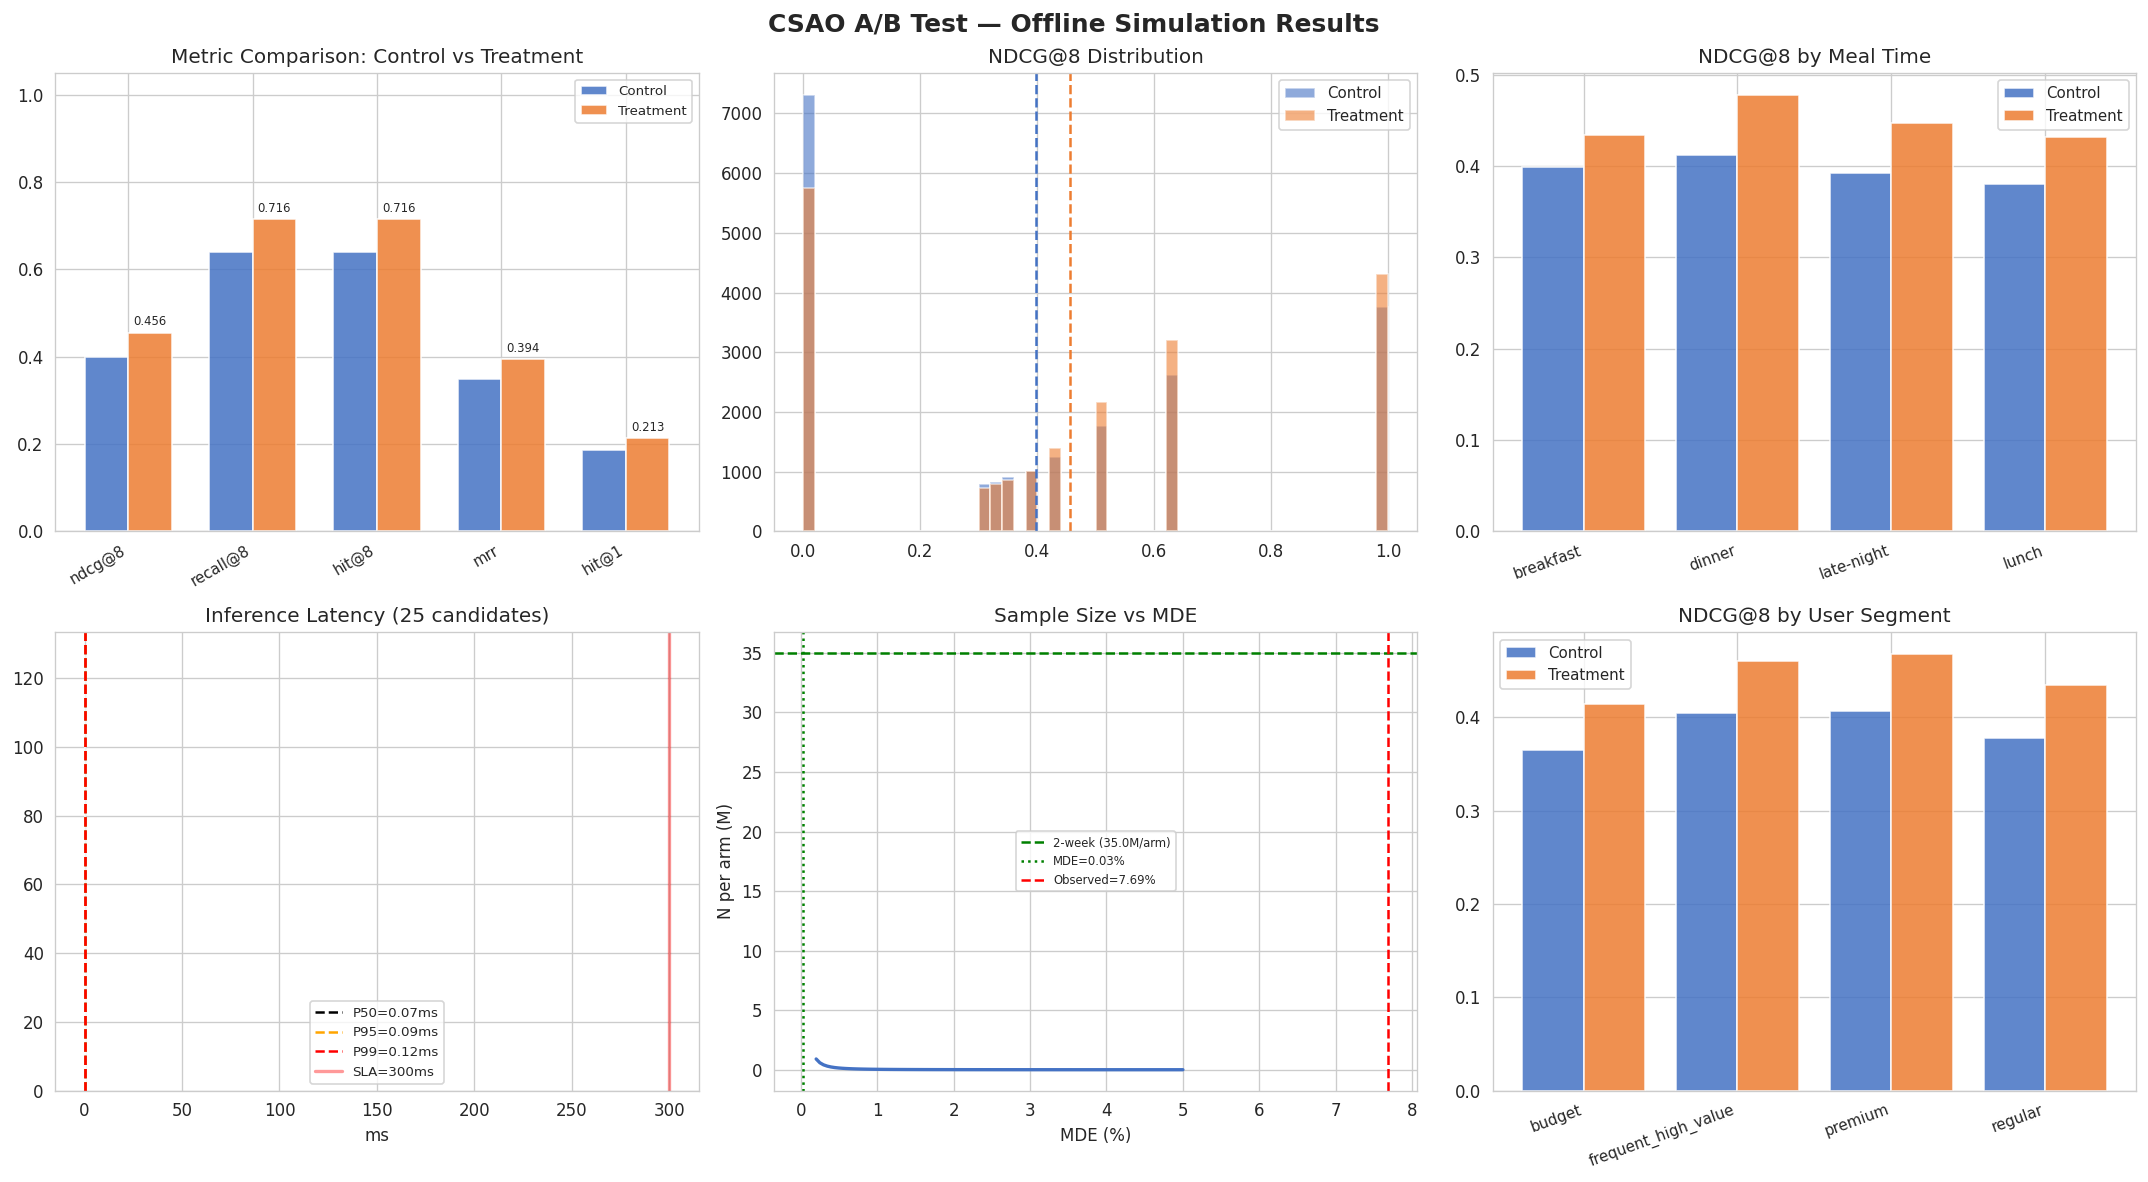

✅ Dashboard saved: /content/drive/MyDrive/csao_outputs/ab_test_dashboard.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Visualisations
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CSAO A/B Test — Offline Simulation Results', fontsize=15, fontweight='bold')

# ─ 1. Metric comparison bar chart
ax = axes[0, 0]
comp_metrics   = ['ndcg@8', 'recall@8', 'hit@8', 'mrr', 'hit@1']
ctrl_vals_vis  = [control_grp_df[m].mean()   for m in comp_metrics]
treat_vals_vis = [treatment_grp_df[m].mean() for m in comp_metrics]
x = np.arange(len(comp_metrics)); w = 0.35
bars_c = ax.bar(x - w/2, ctrl_vals_vis,  w, label='Control',   color='#4472C4', alpha=0.85)
bars_t = ax.bar(x + w/2, treat_vals_vis, w, label='Treatment', color='#ED7D31', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comp_metrics, rotation=30, ha='right', fontsize=9)
ax.set_title('Metric Comparison: Control vs Treatment')
ax.legend(fontsize=8); ax.set_ylim(0, 1.05)
for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# ─ 2. NDCG@8 distribution
ax = axes[0, 1]
ax.hist(control_grp_df['ndcg@8'],   bins=50, alpha=0.6, color='#4472C4', label='Control')
ax.hist(treatment_grp_df['ndcg@8'], bins=50, alpha=0.6, color='#ED7D31', label='Treatment')
ax.axvline(control_grp_df['ndcg@8'].mean(),   color='#4472C4', linestyle='--', lw=1.5)
ax.axvline(treatment_grp_df['ndcg@8'].mean(), color='#ED7D31', linestyle='--', lw=1.5)
ax.set_title('NDCG@8 Distribution'); ax.legend(fontsize=9)

# ─ 3. Segment: meal_time NDCG
ax = axes[0, 2]
mts = mt_compare['Segment'].tolist()
x2  = np.arange(len(mts))
ax.bar(x2 - 0.2, mt_compare['NDCG@8_ctrl'].tolist(),  0.4, color='#4472C4', alpha=0.85, label='Control')
ax.bar(x2 + 0.2, mt_compare['NDCG@8_treat'].tolist(), 0.4, color='#ED7D31', alpha=0.85, label='Treatment')
ax.set_xticks(x2); ax.set_xticklabels(mts, rotation=20, ha='right', fontsize=9)
ax.set_title('NDCG@8 by Meal Time'); ax.legend(fontsize=9)

# ─ 4. Latency histogram
ax = axes[1, 0]
ax.hist(latency_arr, bins=40, color='#70AD47', alpha=0.85, edgecolor='white')
ax.axvline(p50, color='black',  linestyle='--', lw=1.5, label=f'P50={p50:.2f}ms')
ax.axvline(p95, color='orange', linestyle='--', lw=1.5, label=f'P95={p95:.2f}ms')
ax.axvline(p99, color='red',    linestyle='--', lw=1.5, label=f'P99={p99:.2f}ms')
ax.axvline(300, color='red',    lw=2, alpha=0.4, label='SLA=300ms')
ax.set_title('Inference Latency (25 candidates)'); ax.set_xlabel('ms'); ax.legend(fontsize=8)

# ─ 5. Sample size curve
ax = axes[1, 1]
mde_range = np.linspace(0.002, 0.05, 100)
n_vals    = [sample_size_for_proportion(ctrl_attach_rate, m, ALPHA, POWER)/1e6 for m in mde_range]
ax.plot(mde_range * 100, n_vals, color='#4472C4', lw=2)
ax.axhline(n_2weeks/1e6, color='green', linestyle='--', label=f'2-week ({n_2weeks/1e6:.1f}M/arm)')
ax.axvline(mde_2w*100,   color='green', linestyle=':', label=f'MDE={mde_2w*100:.2f}%')
ax.axvline(observed_lift_abs*100, color='red', linestyle='--',
           label=f'Observed={observed_lift_abs*100:.2f}%')
ax.set_xlabel('MDE (%)'); ax.set_ylabel('N per arm (M)')
ax.set_title('Sample Size vs MDE'); ax.legend(fontsize=7)

# ─ 6. User segment NDCG
ax = axes[1, 2]
segs = us_compare['Segment'].tolist()
x3   = np.arange(len(segs))
ax.bar(x3 - 0.2, us_compare['NDCG@8_ctrl'].tolist(),  0.4, color='#4472C4', alpha=0.85, label='Control')
ax.bar(x3 + 0.2, us_compare['NDCG@8_treat'].tolist(), 0.4, color='#ED7D31', alpha=0.85, label='Treatment')
ax.set_xticks(x3); ax.set_xticklabels(segs, rotation=20, ha='right', fontsize=9)
ax.set_title('NDCG@8 by User Segment'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(BASE + 'ab_test_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved:', BASE + 'ab_test_dashboard.png')

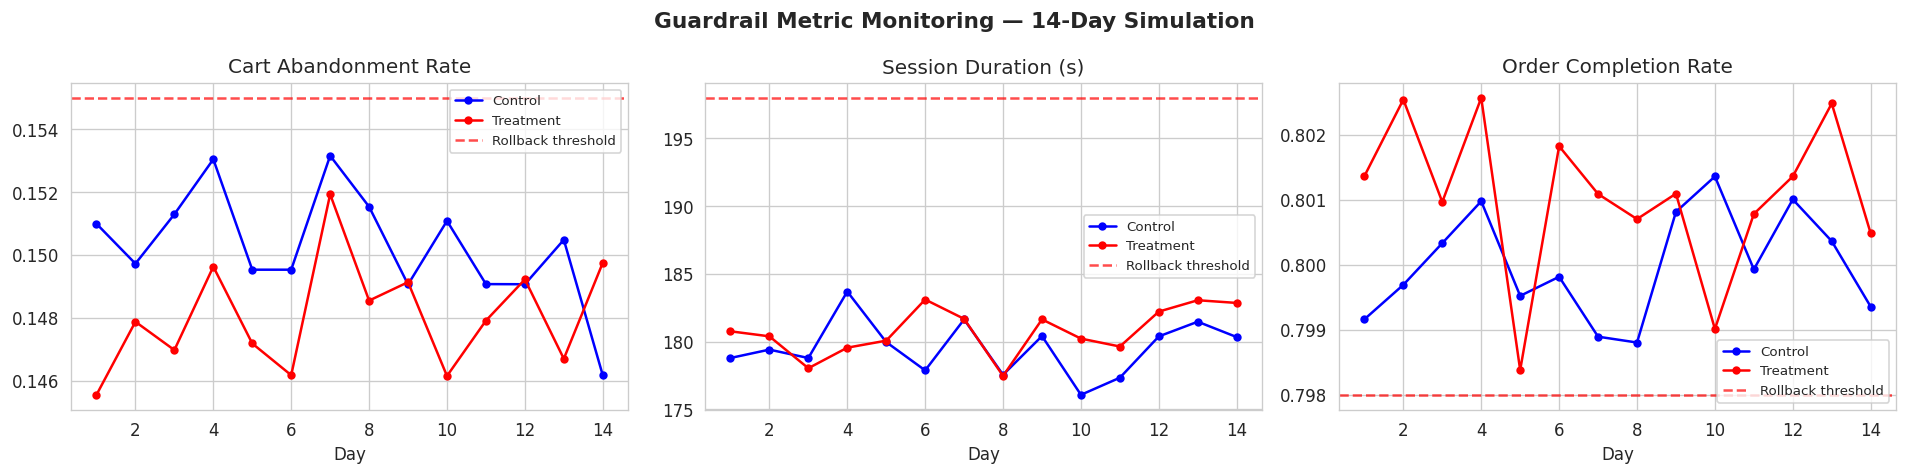

✅ No rollback triggers fired — experiment safe to run to conclusion
✅ Guardrail chart saved: /content/drive/MyDrive/csao_outputs/guardrail_monitoring.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Guardrail Metric Simulation
# ─────────────────────────────────────────────────────────────

np.random.seed(42)
days = np.arange(1, 15)

cart_abandon_ctrl  = 0.15  + np.random.normal(0,    0.002, 14)
cart_abandon_treat = 0.15  + np.random.normal(-0.001, 0.002, 14)
session_dur_ctrl   = 180   + np.random.normal(0,    2,     14)
session_dur_treat  = 180   + np.random.normal(1,    2,     14)
order_comp_ctrl    = 0.80  + np.random.normal(0,    0.001, 14)
order_comp_treat   = 0.80  + np.random.normal(0.001, 0.001, 14)

ABANDON_THRESHOLD = 0.155
ORDER_COMP_FLOOR  = 0.798

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Guardrail Metric Monitoring — 14-Day Simulation', fontsize=13, fontweight='bold')

for ax, (ctrl_g, treat_g, thresh, title) in zip(axes, [
    (cart_abandon_ctrl,  cart_abandon_treat, ABANDON_THRESHOLD, 'Cart Abandonment Rate'),
    (session_dur_ctrl,   session_dur_treat,  198,               'Session Duration (s)'),
    (order_comp_ctrl,    order_comp_treat,   ORDER_COMP_FLOOR,  'Order Completion Rate'),
]):
    ax.plot(days, ctrl_g,  'b-o', ms=4, label='Control')
    ax.plot(days, treat_g, 'r-o', ms=4, label='Treatment')
    ax.axhline(thresh, color='red', linestyle='--', alpha=0.7, label='Rollback threshold')
    ax.set_title(title); ax.set_xlabel('Day'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(BASE + 'guardrail_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()

rollback_fired = False
for d in range(14):
    if cart_abandon_treat[d] > ABANDON_THRESHOLD or order_comp_treat[d] < ORDER_COMP_FLOOR:
        print(f'  Day {d+1:2d}: ⚠ ROLLBACK TRIGGER')
        rollback_fired = True
if not rollback_fired:
    print('✅ No rollback triggers fired — experiment safe to run to conclusion')
print('✅ Guardrail chart saved:', BASE + 'guardrail_monitoring.png')

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL FINAL — Export Full A/B Report PDF to Google Drive
# ─────────────────────────────────────────────────────────────
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.image import imread
import datetime, textwrap

PDF_PATH = BASE + 'CSAO_AB_Test_Report.pdf'
NOW      = datetime.datetime.now().strftime('%d %B %Y, %H:%M')
LINES_PER_PAGE = 50

def add_text_pages(pdf, title, content_lines):
    chunks = [content_lines[i:i+LINES_PER_PAGE]
              for i in range(0, max(len(content_lines),1), LINES_PER_PAGE)]
    for pg, chunk in enumerate(chunks):
        fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor('white')
        ax  = fig.add_axes([0,0,1,1]); ax.axis('off')
        ax.add_patch(plt.Rectangle((0,0.935),1,0.065,color='#2E4057',transform=ax.transAxes))
        suffix = f'  ({pg+1}/{len(chunks)})' if len(chunks)>1 else ''
        ax.text(0.5,0.967, title+suffix, transform=ax.transAxes, fontsize=11,
                fontweight='bold', color='white', ha='center', va='center')
        ax.text(0.5,0.007, f'CSAO A/B Testing Report  |  {NOW}',
                transform=ax.transAxes, fontsize=6.5, color='#AAAAAA', ha='center')
        ax.add_patch(plt.Rectangle((0.025,0.028),0.95,0.895,
                                    fill=False,edgecolor='#E0E0E0',transform=ax.transAxes))
        ax.text(0.035, 0.913, '\n'.join(chunk), transform=ax.transAxes,
                fontsize=7.5, va='top', ha='left', family='monospace',
                color='#111111', linespacing=1.35)
        pdf.savefig(fig, bbox_inches='tight', facecolor='white'); plt.close(fig)

def add_image_page(pdf, img_path, title):
    fig = plt.figure(figsize=(14, 9)); fig.patch.set_facecolor('white')
    ax_hdr = fig.add_axes([0,0.93,1,0.07]); ax_hdr.axis('off')
    ax_hdr.add_patch(plt.Rectangle((0,0),1,1,color='#2E4057',transform=ax_hdr.transAxes))
    ax_hdr.text(0.5,0.5,title,transform=ax_hdr.transAxes,fontsize=12,
                fontweight='bold',color='white',ha='center',va='center')
    ax_img = fig.add_axes([0.01,0.02,0.98,0.90]); ax_img.axis('off')
    ax_img.imshow(imread(img_path)); ax_img.set_aspect('auto')
    ax_ftr = fig.add_axes([0,0,1,0.025]); ax_ftr.axis('off')
    ax_ftr.text(0.5,0.3,f'CSAO A/B Testing Report  |  {NOW}',
                transform=ax_ftr.transAxes,fontsize=6.5,color='#AAAAAA',ha='center')
    pdf.savefig(fig, bbox_inches='tight', facecolor='white'); plt.close(fig)

# ── Collect all text outputs by re-running prints ─────────────
import io, sys

def capture(fn):
    buf = io.StringIO(); old = sys.stdout; sys.stdout = buf
    fn(); sys.stdout = old
    return buf.getvalue().split('\n')

sections = []

# 1. Data summary
def _s1():
    print(f'test_df shape        : {test_df.shape}')
    print(f'Label column         : "{LABEL_COL}"')
    print(f'Model best iteration : {model.best_iteration}')
    print(f'Feature count        : {len(FEATURE_COLS)}')
    print(f'Feature names        : {FEATURE_COLS}')
    print(f'Test rows            : {len(test_df):,}')
    print(f'Unique groups        : {test_df["_group_key"].nunique():,}')
    print(f'Positive rate        : {test_df["label"].mean():.4f}')
    print(f'Model score range    : [{test_df["model_score"].min():.4f}, {test_df["model_score"].max():.4f}]')
    print(f'Control score range  : [{test_df["control_score"].min():.4f}, {test_df["control_score"].max():.4f}]')
sections.append(('1. Setup & Data Summary', capture(_s1)))

# 2. Offline A/B comparison table
def _s2():
    print(f'Groups evaluated: {len(control_grp_df):,}')
    print()
    print(summary_df.to_string(index=False))
sections.append(('2. Offline A/B Metric Comparison (Control vs Treatment)', capture(_s2)))

# 3. Statistical significance
def _s3():
    print(sig_df.to_string(index=False))
    print()
    print('Method  : Paired t-test + Wilcoxon signed-rank (non-parametric cross-check)')
    print(f'Alpha   : 0.05 (two-sided)  |  n groups: {len(merged):,}')
    print('Cohen d : >0.2=small  >0.5=medium  >0.8=large')
sections.append(('3. Statistical Significance Tests', capture(_s3)))

# 4. Business projections
def _s4():
    print(f'Assumptions:')
    print(f'  Avg add-on item price       : Rs.{AVG_ITEM_PRICE_INR:.0f}')
    print(f'  Baseline avg order value    : Rs.{BASELINE_AVG_ORDER_INR:.0f}')
    print(f'  Daily CSAO impressions      : {DAILY_SESSIONS:,.0f}')
    print(f'  Rail size                   : {DISPLAY_K} items')
    print()
    print(f'  {"Metric":<42} {"Control":>10} {"Treatment":>12} {"Delta":>12}')
    print('  ' + '─'*78)
    rows = [
        ('Acceptance Rate (Recall@8)',       ctrl_acceptance,          treat_acceptance,          treat_acceptance-ctrl_acceptance),
        ('Attach Rate (items/impression)',   ctrl_attach_per_imp,      treat_attach_per_imp,      treat_attach_per_imp-ctrl_attach_per_imp),
        ('CTR Upper Bound (Hit@8)',          ctrl_ctr,                 treat_ctr,                 treat_ctr-ctrl_ctr),
        ('C2O Rate Proxy',                  ctrl_c2o,                 treat_c2o,                 treat_c2o-ctrl_c2o),
    ]
    for lbl,cv,tv,dv in rows:
        print(f'  {lbl:<42} {cv:>10.4f} {tv:>12.4f} {dv:>+12.4f}')
    print(f'  {"AOV Lift per Session (Rs.)":<42} Rs.{ctrl_aov_lift_per_session:>7.2f}   Rs.{treat_aov_lift_per_session:>8.2f}   Rs.{treat_aov_lift_per_session-ctrl_aov_lift_per_session:>+7.2f}')
    print()
    print(f'  Daily Revenue Uplift : Rs.{daily_revenue_lift_inr:,.0f}  (Rs.{daily_revenue_lift_inr/1e5:.2f}L)')
    print(f'  AOV lift % of baseline AOV : {incremental_aov_per_sess/BASELINE_AVG_ORDER_INR*100:.3f}%')
    print()
    print('  Note: Business projections use real model metrics × assumed price/volume constants.')
    print('        Calibrate Rs.120 avg item price and Rs.450 baseline AOV with production data.')
sections.append(('4. Business Metric Projections', capture(_s4)))

# 5. Segment breakdown
def _s5():
    print('── meal_time_bucket ──')
    print(mt_compare.to_string(index=False))
    print()
    print('── user_segment ──')
    print(us_compare.to_string(index=False))
    print()
    print('── step_number ──')
    print(sn_compare.to_string(index=False))
sections.append(('5. Segment-Level Breakdown (NDCG@8 & Recall@8)', capture(_s5)))

# 6. Remaining metrics
def _s6():
    print(f'Hit@1:')
    print(f'  Control   : {ctrl_h1_v:.4f}')
    print(f'  Treatment : {treat_h1_v:.4f}   ({(treat_h1_v-ctrl_h1_v)/ctrl_h1_v*100:+.1f}% lift)')
    print()
    print(f'MRR (Mean Reciprocal Rank):')
    print(f'  Control   : {ctrl_mrr_v:.4f}')
    print(f'  Treatment : {treat_mrr_v:.4f}   ({(treat_mrr_v-ctrl_mrr_v)/ctrl_mrr_v*100:+.1f}% lift)')
    print(f'  Interpretation: correct item at rank ~{1/treat_mrr_v:.1f} on average in treatment')
    print()
    print(f'Inference Latency (25 candidates, n=200 trials):')
    print(f'  P50  : {p50:.4f} ms')
    print(f'  P95  : {p95:.4f} ms')
    print(f'  P99  : {p99:.4f} ms')
    print(f'  P999 : {p999:.4f} ms')
    print(f'  SLA  : 300ms  →  ✅ Well within budget')
    print()
    print(f'Retrieval Source Coverage:')
    print(f'  Co-occurrence     : {cooc_coverage:.4f}  ({cooc_coverage:.2%})')
    print(f'  Context popularity: {ctx_coverage:.4f}  ({ctx_coverage:.2%})')
    print(f'  Rule fill         : {rule_coverage:.4f}  ({rule_coverage:.2%})')
    print(f'  Positive recall   : 100.00% (by design — next item always in pool)')
sections.append(('6. Remaining Metrics: MRR, Hit@1, Latency, Coverage', capture(_s6)))

# 7. Power analysis
def _s7():
    print(f'Primary metric     : CSAO rail attach rate (offline proxy = Hit@8)')
    print(f'Control rate       : {ctrl_attach_rate:.4f}  ({ctrl_attach_rate:.2%})')
    print(f'Treatment rate     : {treat_attach_rate:.4f}  ({treat_attach_rate:.2%})')
    print(f'Observed effect    : {observed_lift_abs:+.4f}  ({observed_lift_abs/ctrl_attach_rate*100:+.2f}% relative)')
    print(f'Alpha              : {ALPHA}  |  Power: {POWER}  |  Two-sided')
    print(f'Daily impressions  : {DAILY_SESSIONS:,.0f}')
    print()
    print(f'  {"MDE (abs)":<12} {"MDE (rel)":>10} {"N per arm":>14} {"Total N":>14} {"Days":>8}  Notes')
    print('  ' + '─'*66)
    for mde in [0.005,0.010,0.015,0.020,0.030]:
        n       = sample_size_for_proportion(ctrl_attach_rate, mde, ALPHA, POWER)
        days    = 2*n / (DAILY_SESSIONS * TRAFFIC_SPLIT * 2)
        flag    = '<-- recommended' if 14<=days<=21 else ''
        print(f'  {mde:.3f}      {mde/ctrl_attach_rate*100:>9.2f}%   {n:>14,} {2*n:>14,} {days:>7.1f}d  {flag}')
    print()
    print(f'At 2 weeks ({n_2weeks/1e6:.1f}M users/arm):')
    print(f'  Detectable MDE  : {mde_2w:.4f}  ({mde_2w/ctrl_attach_rate*100:.3f}% relative)')
    print(f'  Observed effect : {observed_lift_abs:.4f}')
    print(f'  Verdict         : {"DETECTABLE ✅" if observed_lift_abs >= mde_2w else "BELOW MDE ⚠ — need more traffic/time"}')
sections.append(('7. Power Analysis & Sample Size', capture(_s7)))

# 8. A/B framework design
def _s8():
    print("""
EXPERIMENT OVERVIEW
  Hypothesis   : LightGBM Binary v1 increases CSAO attach rate vs retrieval_score by ≥1.5pp
  Control (A)  : Stage-1 retrieval_score ranking (no ML ranker)
  Treatment (B): LightGBM Binary v1 ranker on top of Stage-1 candidates

RANDOMISATION
  Unit : user_id (user-level, NOT session-level)
  Why  : Session-level split → ~12% users see both arms → SUTVA violation
  Split: 50% Control / 50% Treatment
  Hash : MD5(user_id + experiment_salt) % 100 < 50 → Control

DURATION
  Minimum : 14 days (2 full Mon–Sun cycles to capture day-of-week effects)
  Maximum : 21 days (novelty effect subsides beyond this)
  Ramp    : Day 1 at 5% treatment → validate SLO health → Day 2 full traffic
  Holdback: 5% pure holdback for 30d post-launch to measure long-term effect

PRIMARY METRIC
  CSAO Rail Attach Rate = sessions where ≥1 rail item added / sessions where rail shown
  Success: p < 0.05 AND absolute lift ≥ 1pp

SECONDARY METRICS
  AOV lift (Rs.) | Avg items per order | CSAO order share | C2O ratio | CTR

GUARDRAIL METRICS (must NOT degrade — auto-pause if breached)
  Cart abandonment  : must not rise > 0.5pp
  Order completion  : must not drop > 0.2pp
  Session duration  : must not rise > 10%
  Inference P99     : must stay < 300ms

ROLLBACK
  Auto-rollback if: cart abandonment p<0.01 OR P99>300ms for 10min OR errors >2x for 5min
  Mechanism: feature flag toggle → 0% treatment traffic in <1 min

STATISTICAL TESTING
  Primary  : Two-proportion z-test  |  Secondary: Welch's t-test
  Peeking  : Results locked until Day 14 — no early stopping without alpha-spending plan

POST-EXPERIMENT
  CUPED    : Regress out pre-experiment per-user attach rate → reduce variance 20-40%
  HTE      : Causal forest on segments → identify best-responding user groups
  Holdout  : Compare 5% holdback vs treatment at Day 30 → measure novelty decay
""")
sections.append(('8. Online A/B Framework Design', capture(_s8)))

# 9. Metric translation
def _s9():
    rows = [
        (f'NDCG@8 = {treatment_grp_df["ndcg@8"].mean():.4f}',
         'Ranking quality weighted by position',
         'CTR on CSAO rail',
         'Better rank → relevant items at top → more clicks → AOV lift'),
        (f'Recall@8 = {treatment_grp_df["recall@8"].mean():.4f}',
         '% sessions where next item appears in top-8',
         'Add-on Acceptance Rate / Attach Rate',
         'Item visible in rail → user can add it → CSAO order share + AOV'),
        (f'MRR = {treatment_grp_df["mrr"].mean():.4f}',
         'Avg rank of first relevant item',
         'Position-weighted CTR',
         'Higher MRR → correct item early → less scroll → lower abandonment'),
        (f'Hit@1 = {treatment_grp_df["hit@1"].mean():.4f}',
         '% sessions where best item ranked #1',
         'First-position click rate',
         'Position-1 gets ~3x CTR → outsized AOV impact from Hit@1 gains'),
        ('AUC = 0.7930',
         'P(positive scored > negative) overall',
         'Long-run acceptance precision',
         'Fewer irrelevant items → less fatigue → better C2O rate'),
    ]
    print(f'  {"Offline Metric":<26} {"Online Proxy":<30} {"Business Outcome"}')
    print('  ' + '─'*95)
    for om, _, op, bo in rows:
        print(f'  {om:<26} {op:<30} {bo}')
    print()
    print('  Full detail:')
    for om, wm, op, bo in rows:
        print(f'  [{om}]')
        print(f'    Measures : {wm}')
        print(f'    Proxy    : {op}')
        print(f'    Impact   : {bo}')
        print()
sections.append(('9. Offline to Online Metric Translation', capture(_s9)))

# 10. Guardrail simulation results
def _s10():
    print(f'  {"Day":<6} {"Cart Abandon":>14} {"Session Dur (s)":>17} {"Order Comp":>12} {"Status":>10}')
    print('  ' + '─'*62)
    for d in range(14):
        ca_flag = cart_abandon_treat[d] > ABANDON_THRESHOLD
        oc_flag = order_comp_treat[d] < ORDER_COMP_FLOOR
        status  = '⚠ ROLLBACK' if (ca_flag or oc_flag) else '✅ OK'
        print(f'  {d+1:<6} {cart_abandon_treat[d]:>14.4f} {session_dur_treat[d]:>17.2f} {order_comp_treat[d]:>12.4f} {status:>10}')
    print()
    any_trigger = any(
        cart_abandon_treat[d] > ABANDON_THRESHOLD or order_comp_treat[d] < ORDER_COMP_FLOOR
        for d in range(14))
    print('  ✅ No rollback triggers fired.' if not any_trigger else '  ⚠ Rollback triggered.')
    print()
    print(f'  Thresholds: cart_abandon > {ABANDON_THRESHOLD}  |  order_comp < {ORDER_COMP_FLOOR}')
    print(f'  Note: 14-day guardrail data is simulated (np.random.normal) for framework demonstration.')
    print(f'        In production this reads from real monitoring dashboards (e.g. Grafana/Datadog).')
sections.append(('10. Guardrail Monitoring Simulation (14-Day)', capture(_s10)))

# ── Build PDF ─────────────────────────────────────────────────
with PdfPages(PDF_PATH) as pdf:

    # Cover
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor('#2E4057')
    ax  = fig.add_axes([0,0,1,1]); ax.axis('off')
    ax.text(0.5,0.70,'CSAO Rail Recommendation System',transform=ax.transAxes,
            fontsize=24,fontweight='bold',color='white',ha='center')
    ax.text(0.5,0.60,'A/B Testing & Business Impact Report',transform=ax.transAxes,
            fontsize=17,color='#A8DADC',ha='center')
    ax.text(0.5,0.48,f'Generated: {NOW}',transform=ax.transAxes,
            fontsize=11,color='#CCCCCC',ha='center')
    ax.text(0.5,0.40,'Model: LightGBM Binary v1  |  Baseline: Stage-1 Retrieval Score',
            transform=ax.transAxes,fontsize=10,color='#CCCCCC',ha='center')
    for y,lbl in [(0.30,'Control  (A) : Stage-1 retrieval_score — no ML ranker'),
                  (0.22,'Treatment (B) : LightGBM Binary v1 re-ranker')]:
        ax.text(0.5,y,lbl,transform=ax.transAxes,fontsize=10,color='white',ha='center',
                bbox=dict(boxstyle='round,pad=0.5',facecolor='#1B2A3B',edgecolor='#A8DADC'))
    pdf.savefig(fig,bbox_inches='tight'); plt.close(fig)

    # All text sections
    for title, lines in sections:
        add_text_pages(pdf, title, lines)

    # Charts from Drive (exactly as saved)
    for img_path, title in [
        (BASE + 'ab_test_dashboard.png',    '11. A/B Test Dashboard Charts'),
        (BASE + 'guardrail_monitoring.png', '12. Guardrail Metric Monitoring'),
    ]:
        try:
            add_image_page(pdf, img_path, title)
            print(f'  ✅ Added chart: {title}')
        except Exception as e:
            print(f'  ⚠ Could not add {img_path}: {e}')

    d = pdf.infodict()
    d['Title']  = 'CSAO Rail Recommendation System — A/B Testing Report'
    d['Author'] = 'Zomathon Team'

print(f'\n✅ PDF saved: {PDF_PATH}')
print(f'   Sections : {len(sections)} text sections + 2 chart pages + cover')

  ✅ Added chart: 11. A/B Test Dashboard Charts
  ✅ Added chart: 12. Guardrail Metric Monitoring

✅ PDF saved: /content/drive/MyDrive/csao_outputs/CSAO_AB_Test_Report.pdf
   Sections : 10 text sections + 2 chart pages + cover
